# Experimental Evaluation

In [1]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

font = {
        'size'   : 11}
mpl.rc('font', **font)

## Helper functions

In [2]:
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)

In [3]:
def set_size(width_pt, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)


In [4]:
def set_square_size(width_pt, fraction=1):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    return (fig_width_in, fig_width_in)

In [5]:
def csv_info(table, verdict_str, time_str):
    print("Number of instances:", table.shape[0])
    print("SAT:", table.query(verdict_str + " == 'sat'").shape[0])
    print("UNSAT:", table.query(verdict_str + " == 'unsat'").shape[0])
    print("SAT or UNSAT:", table.query(verdict_str + " == 'sat' or " + verdict_str + " == 'unsat'").shape[0])
    print("UNKNOWN:", table.query(verdict_str + " == 'unknown'").shape[0])
    print("TIMEOUT:", table.query(verdict_str + " == 'timeout'").shape[0])
    count_errors = table[table[verdict_str].str.contains("error:", na=False)].shape[0]
    print("ERROR:", count_errors)

In [6]:
def plot_survival(table, solvers, verdict_types, labels, colors, y_text, plot_name):
    solver_times_sorted = {}
    solver_cumulative_sol = {}
    solver_plot = {}
    
    plt.figure(figsize=(8,6))
    
    for solver in solvers:
        verdict_col = f'verdict_{solver}'
        time_col = f'time_{solver}'
        
        times = table.loc[table[verdict_col].isin(verdict_types), time_col]
        times = pd.to_numeric(times, errors='coerce').dropna()
    
        solver_times_sorted[solver] = np.sort(times)
        solver_cumulative_sol[solver] = np.arange(1, len(solver_times_sorted[solver])+1)
    
        solver_plot[solver] = np.clip(solver_times_sorted[solver], min_time, None)
        solver_plot[solver] = np.append(solver_plot[solver], max_time)
        solver_cumulative_sol[solver] = np.append(solver_cumulative_sol[solver], solver_cumulative_sol[solver][-1])
    
        plt.step(solver_plot[solver], solver_cumulative_sol[solver], where='post', color = colors[solver], label=labels[solver])
    
    plt.xlabel('Time (seconds)')
    plt.ylabel(y_text)
    plt.legend()
    plt.grid(True, which='both')
    
    plt.xscale('log', base=10)
    ax = plt.gca()
    ax.set_xlim(min_time, max_time)
    plt.xticks([min_time*(10**i) for i in range(int(np.log10(max_time))+2)])
    
    plt.savefig(plot_name, format="pgf", bbox_inches="tight")
    plt.show()

In [7]:
def plot_scatter_solvers(table, solvers, verdict_types, labels, colors, plot_name, min_time=None, max_time=None, category_col=None, category_colors=None, category_labels=None, logscale=True):
    """
    Create a scatter plot comparing the runtime of two solvers.
    
    Parameters:
    - table: DataFrame with solver results
    - solvers: list of exactly 2 solver names
    - verdict_types: list of verdict types to include
    - labels: dict mapping solver names to display labels
    - colors: dict mapping solver names to colors (not used if category_col is provided)
    - plot_name: filename for the output pgf file
    - min_time: minimum time for axis (optional)
    - max_time: maximum time for axis (optional)
    - category_col: column name containing categories (optional)
    - category_colors: dict mapping category values to colors (required if category_col is provided)
    - category_labels: dict mapping category values to display labels (required if category_col is provided)
    - logscale: boolean to use logarithmic scale (default: True)
    """
    
    # Ensure we have exactly 2 solvers
    if len(solvers) != 2:
        raise ValueError("This function expects exactly 2 solvers")
    
    solver1, solver2 = solvers[0], solvers[1]
    verdict_col1 = f'verdict_{solver1}'
    time_col1 = f'time_{solver1}'
    verdict_col2 = f'verdict_{solver2}'
    time_col2 = f'time_{solver2}'
    
    # Filter for instances solved by both solvers with the specified verdicts
    mask1 = table[verdict_col1].isin(verdict_types)
    mask2 = table[verdict_col2].isin(verdict_types)
    mask = mask1 & mask2
    
    times1 = pd.to_numeric(table.loc[mask, time_col1], errors='coerce')
    times2 = pd.to_numeric(table.loc[mask, time_col2], errors='coerce')
    
    # Drop NaN values
    valid_mask = times1.notna() & times2.notna()
    times1 = times1[valid_mask]
    times2 = times2[valid_mask]
    
    # Keep track of categories if provided
    if category_col is not None:
        categories_data = table.loc[mask, category_col][valid_mask]
    
    times1_vals = times1.values
    times2_vals = times2.values
    
    # Set axis limits if not provided
    if min_time is None:
        min_time = min(np.min(times1_vals), np.min(times2_vals)) * 0.9
    if max_time is None:
        max_time = max(np.max(times1_vals), np.max(times2_vals)) * 1.1
    
    plt.figure(figsize=(8, 8))
    
    # Plot scatter points
    if category_col is not None:
        # Plot by categories
        categories = categories_data.values
        for category in sorted(set(categories)):
            cat_mask = categories == category
            color = category_colors.get(category, 'gray')
            label = category_labels.get(category, str(category))
            plt.scatter(times1_vals[cat_mask], times2_vals[cat_mask], color=color, alpha=0.6, s=50, label=label)
        plt.legend()
    else:
        # Plot all points with same color
        plt.scatter(times1_vals, times2_vals, color=colors[solver1], alpha=0.6, s=50)
    
    # Add diagonal reference line (y=x)
    diag_min = min(min_time, min_time)
    diag_max = max(max_time, max_time)
    plt.plot([diag_min, diag_max], [diag_min, diag_max], 'k--', alpha=0.4, linewidth=1)
    
    # Labels and formatting
    plt.xlabel(f'Time {labels[solver1]} (seconds)', fontsize=12)
    plt.ylabel(f'Time {labels[solver2]} (seconds)', fontsize=12)
    plt.grid(True, which='both', alpha=0.3)
    
    # Log scales (conditional)
    if logscale:
        plt.xscale('log', base=10)
        plt.yscale('log', base=10)
    
    # Set axis limits
    plt.xlim(min_time, max_time)
    plt.ylim(min_time, max_time)
    
    plt.savefig(plot_name, format="pgf", bbox_inches="tight")
    plt.show()

# Benchmark: Split 2-20

## Instances: Modular

In [8]:
par_2_20_modular =  pd.read_csv("CSV/modular/2-20/modular-2-par.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
csv_info(par_2_20_modular, "verdict_par_2_20", "time_par_2_20")
par_2_20_modular

Number of instances: 30
SAT: 6
UNSAT: 24
SAT or UNSAT: 30
UNKNOWN: 0
TIMEOUT: 0
ERROR: 0


,instance,verdict_par_2_20,time_par_2_20
0,ai-instances/modular/modular_15.smt2,unsat,14.27
1,ai-instances/modular/modular_03.smt2,sat,2.32
2,ai-instances/modular/modular_27.smt2,unsat,2.36
3,ai-instances/modular/modular_30.smt2,unsat,1.62
4,ai-instances/modular/modular_08.smt2,unsat,6.13
5,ai-instances/modular/modular_04.smt2,sat,0.48
6,ai-instances/modular/modular_13.smt2,unsat,7.40
7,ai-instances/modular/modular_26.smt2,unsat,2.43
8,ai-instances/modular/modular_14.smt2,unsat,4.13
9,ai-instances/modular/modular_24.smt2,unsat,53.85


In [9]:
sym_2_20_modular =  pd.read_csv("CSV/modular/2-20/modular-2-sym.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})
csv_info(sym_2_20_modular, "verdict_sym_2_20", "time_sym_2_20")
sym_2_20_modular

Number of instances: 30
SAT: 6
UNSAT: 24
SAT or UNSAT: 30
UNKNOWN: 0
TIMEOUT: 0
ERROR: 0


,instance,verdict_sym_2_20,time_sym_2_20
0,ai-instances/modular/modular_22.smt2,unsat,301.77
1,ai-instances/modular/modular_16.smt2,unsat,89.28
2,ai-instances/modular/modular_29.smt2,unsat,3.16
3,ai-instances/modular/modular_07.smt2,unsat,2.39
4,ai-instances/modular/modular_10.smt2,unsat,8.75
5,ai-instances/modular/modular_13.smt2,unsat,15.34
6,ai-instances/modular/modular_24.smt2,unsat,307.71
7,ai-instances/modular/modular_21.smt2,unsat,209.93
8,ai-instances/modular/modular_20.smt2,unsat,124.58
9,ai-instances/modular/modular_14.smt2,unsat,20.71


In [10]:
modular_2_20 = par_2_20_modular
modular_2_20 = sym_2_20_modular.join(modular_2_20.set_index("instance"), on="instance", how="left")
modular_2_20['category'] = "modular"
modular_2_20

,instance,verdict_sym_2_20,time_sym_2_20,verdict_par_2_20,time_par_2_20,category
0,ai-instances/modular/modular_22.smt2,unsat,301.77,unsat,101.29,modular
1,ai-instances/modular/modular_16.smt2,unsat,89.28,unsat,28.08,modular
2,ai-instances/modular/modular_29.smt2,unsat,3.16,unsat,2.08,modular
3,ai-instances/modular/modular_07.smt2,unsat,2.39,unsat,1.74,modular
4,ai-instances/modular/modular_10.smt2,unsat,8.75,unsat,4.03,modular
5,ai-instances/modular/modular_13.smt2,unsat,15.34,unsat,7.40,modular
6,ai-instances/modular/modular_24.smt2,unsat,307.71,unsat,53.85,modular
7,ai-instances/modular/modular_21.smt2,unsat,209.93,unsat,52.16,modular
8,ai-instances/modular/modular_20.smt2,unsat,124.58,unsat,31.41,modular
9,ai-instances/modular/modular_14.smt2,unsat,20.71,unsat,4.13,modular


## Instances: Random E

In [11]:
par_2_20_random_e =  pd.read_csv("CSV/random/2-20/random-2-par-e.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
csv_info(par_2_20_random_e, "verdict_par_2_20", "time_par_2_20")
par_2_20_random_e

Number of instances: 30
SAT: 23
UNSAT: 6
SAT or UNSAT: 29
UNKNOWN: 1
TIMEOUT: 0
ERROR: 0


,instance,verdict_par_2_20,time_par_2_20
0,ai-instances/random/random_25.smt2,unsat,38.60
1,ai-instances/random/random_26.smt2,sat,0.06
2,ai-instances/random/random_30.smt2,sat,0.30
3,ai-instances/random/random_07.smt2,sat,18.26
4,ai-instances/random/random_09.smt2,sat,121.31
5,ai-instances/random/random_19.smt2,unsat,26.75
6,ai-instances/random/random_20.smt2,sat,0.05
7,ai-instances/random/random_05.smt2,unsat,94.25
8,ai-instances/random/random_21.smt2,unknown,252.86
9,ai-instances/random/random_08.smt2,sat,0.06


In [12]:
sym_2_20_random_e =  pd.read_csv("CSV/random/2-20/random-2-sym-e.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})
csv_info(sym_2_20_random_e, "verdict_sym_2_20", "time_sym_2_20")
sym_2_20_random_e

Number of instances: 30
SAT: 24
UNSAT: 6
SAT or UNSAT: 30
UNKNOWN: 0
TIMEOUT: 0
ERROR: 0


,instance,verdict_sym_2_20,time_sym_2_20
0,ai-instances/random/random_22.smt2,sat,0.04
1,ai-instances/random/random_07.smt2,sat,8.33
2,ai-instances/random/random_27.smt2,sat,0.07
3,ai-instances/random/random_08.smt2,sat,0.07
4,ai-instances/random/random_13.smt2,sat,0.04
5,ai-instances/random/random_20.smt2,sat,0.05
6,ai-instances/random/random_18.smt2,sat,1.30
7,ai-instances/random/random_01.smt2,unsat,0.07
8,ai-instances/random/random_14.smt2,sat,0.59
9,ai-instances/random/random_23.smt2,sat,0.04


In [13]:
random_2_20_e = par_2_20_random_e
random_2_20_e = sym_2_20_random_e.join(random_2_20_e.set_index("instance"), on="instance", how="left")
random_2_20_e['category'] = "random_e"
random_2_20_e

,instance,verdict_sym_2_20,time_sym_2_20,verdict_par_2_20,time_par_2_20,category
0,ai-instances/random/random_22.smt2,sat,0.04,sat,0.13,random_e
1,ai-instances/random/random_07.smt2,sat,8.33,sat,18.26,random_e
2,ai-instances/random/random_27.smt2,sat,0.07,sat,0.16,random_e
3,ai-instances/random/random_08.smt2,sat,0.07,sat,0.06,random_e
4,ai-instances/random/random_13.smt2,sat,0.04,sat,0.04,random_e
5,ai-instances/random/random_20.smt2,sat,0.05,sat,0.05,random_e
6,ai-instances/random/random_18.smt2,sat,1.30,sat,1.92,random_e
7,ai-instances/random/random_01.smt2,unsat,0.07,unsat,0.07,random_e
8,ai-instances/random/random_14.smt2,sat,0.59,sat,0.52,random_e
9,ai-instances/random/random_23.smt2,sat,0.04,sat,0.04,random_e


## Instances: Mixed E

In [14]:
par_2_20_mixed_e =  pd.read_csv("CSV/mixed/2-20/mixed-2-par-e.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
csv_info(par_2_20_mixed_e, "verdict_par_2_20", "time_par_2_20")
par_2_20_mixed_e

Number of instances: 30
SAT: 21
UNSAT: 4
SAT or UNSAT: 25
UNKNOWN: 3
TIMEOUT: 2
ERROR: 0


,instance,verdict_par_2_20,time_par_2_20
0,ai-instances/random-mixed/mixed_27.smt2,sat,3.22
1,ai-instances/random-mixed/mixed_23.smt2,timeout,600.00
2,ai-instances/random-mixed/mixed_26.smt2,unsat,378.09
3,ai-instances/random-mixed/mixed_18.smt2,sat,0.59
4,ai-instances/random-mixed/mixed_14.smt2,unsat,232.91
5,ai-instances/random-mixed/mixed_08.smt2,sat,0.25
6,ai-instances/random-mixed/mixed_13.smt2,sat,0.57
7,ai-instances/random-mixed/mixed_19.smt2,unknown,237.94
8,ai-instances/random-mixed/mixed_16.smt2,sat,1.76
9,ai-instances/random-mixed/mixed_07.smt2,timeout,600.00


In [15]:
sym_2_20_mixed_e =  pd.read_csv("CSV/mixed/2-20/mixed-2-sym-e.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})
csv_info(sym_2_20_mixed_e, "verdict_sym_2_20", "time_sym_2_20")
sym_2_20_mixed_e

Number of instances: 30
SAT: 25
UNSAT: 5
SAT or UNSAT: 30
UNKNOWN: 0
TIMEOUT: 0
ERROR: 0


,instance,verdict_sym_2_20,time_sym_2_20
0,ai-instances/random-mixed/mixed_02.smt2,sat,0.67
1,ai-instances/random-mixed/mixed_11.smt2,sat,1.12
2,ai-instances/random-mixed/mixed_19.smt2,sat,69.96
3,ai-instances/random-mixed/mixed_06.smt2,sat,2.39
4,ai-instances/random-mixed/mixed_28.smt2,sat,0.05
5,ai-instances/random-mixed/mixed_05.smt2,sat,4.36
6,ai-instances/random-mixed/mixed_22.smt2,sat,0.19
7,ai-instances/random-mixed/mixed_21.smt2,sat,21.72
8,ai-instances/random-mixed/mixed_14.smt2,unsat,196.38
9,ai-instances/random-mixed/mixed_20.smt2,sat,1.08


In [16]:
mixed_2_20_e = par_2_20_mixed_e
mixed_2_20_e = sym_2_20_mixed_e.join(mixed_2_20_e.set_index("instance"), on="instance", how="left")
mixed_2_20_e['category'] = "random_e"
mixed_2_20_e

,instance,verdict_sym_2_20,time_sym_2_20,verdict_par_2_20,time_par_2_20,category
0,ai-instances/random-mixed/mixed_02.smt2,sat,0.67,sat,5.65,random_e
1,ai-instances/random-mixed/mixed_11.smt2,sat,1.12,unknown,232.49,random_e
2,ai-instances/random-mixed/mixed_19.smt2,sat,69.96,unknown,237.94,random_e
3,ai-instances/random-mixed/mixed_06.smt2,sat,2.39,sat,13.11,random_e
4,ai-instances/random-mixed/mixed_28.smt2,sat,0.05,sat,0.06,random_e
5,ai-instances/random-mixed/mixed_05.smt2,sat,4.36,sat,26.57,random_e
6,ai-instances/random-mixed/mixed_22.smt2,sat,0.19,sat,0.15,random_e
7,ai-instances/random-mixed/mixed_21.smt2,sat,21.72,sat,21.42,random_e
8,ai-instances/random-mixed/mixed_14.smt2,unsat,196.38,unsat,232.91,random_e
9,ai-instances/random-mixed/mixed_20.smt2,sat,1.08,sat,1.85,random_e


# Combine CSVs

In [17]:
table_2_20 = pd.concat([modular_2_20, random_2_20_e, mixed_2_20_e], ignore_index=True)
table_2_20

,instance,verdict_sym_2_20,time_sym_2_20,verdict_par_2_20,time_par_2_20,category
0,ai-instances/modular/modular_22.smt2,unsat,301.77,unsat,101.29,modular
1,ai-instances/modular/modular_16.smt2,unsat,89.28,unsat,28.08,modular
2,ai-instances/modular/modular_29.smt2,unsat,3.16,unsat,2.08,modular
3,ai-instances/modular/modular_07.smt2,unsat,2.39,unsat,1.74,modular
4,ai-instances/modular/modular_10.smt2,unsat,8.75,unsat,4.03,modular
...,...,...,...,...,...,...
85,ai-instances/random-mixed/mixed_04.smt2,sat,0.22,sat,0.53,random_e
86,ai-instances/random-mixed/mixed_24.smt2,sat,3.31,sat,2.14,random_e
87,ai-instances/random-mixed/mixed_16.smt2,sat,0.32,sat,1.76,random_e
88,ai-instances/random-mixed/mixed_15.smt2,sat,0.61,sat,15.40,random_e


# Scatter plot for 2-20

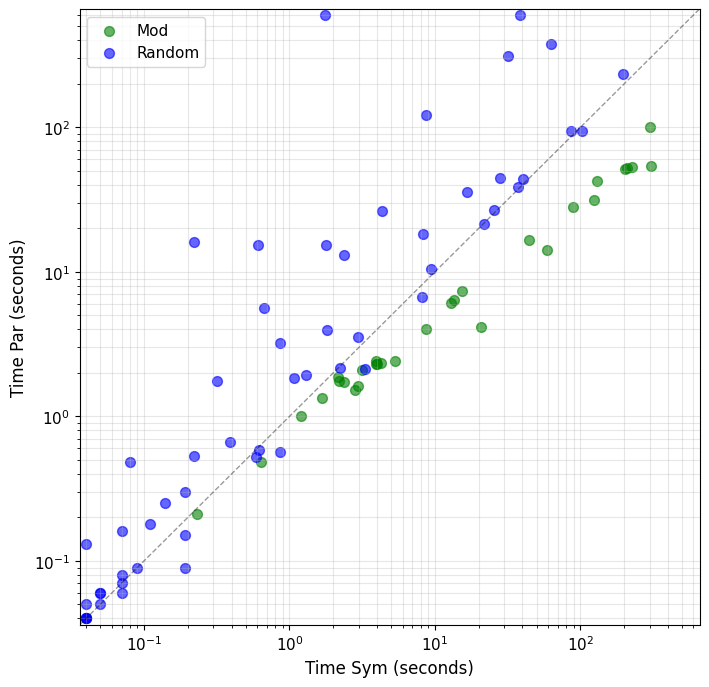

In [18]:
plot_scatter_solvers(
    table = table_2_20,
    solvers=['sym_2_20', 'par_2_20'],
    verdict_types=['sat', 'unsat', 'timeout'],
    labels={'sym_2_20': 'Sym', 'par_2_20': 'Par'},
    colors={'sym_2_20': 'blue', 'par_2_20': 'red'},  # ignored when using categories
    plot_name='solver_comparison.pgf',
    category_col='category',                         # column with categories
    category_colors={
        'modular': 'green',
        'divisibility': 'red',
        'random_e': 'blue'
    },
    category_labels={
        'modular': 'Mod',
        'divisibility': 'Div',
        'random_e': 'Random'
    }, 
    logscale = True
)